<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/03.%20Dimensionality%20Reduction%20/%20Chapter_03_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Dimensionality Reduction Techniques

Imagine you are making soup from scratch in your home's kitchen. This is the first time you've prepared this type of soup, so you decide to follow a recipe from a cookbook you have on hand. However, your ego gets the best of you, and you decide you can make the soup better by adding a few more ingredients and reducing a few. After heating up your new concoction, the taste test reveals...you've ruined the soup!

While we don't often get recipes for building ML models (although this book is full of them!), the analogy holds: the right combination of ingredients -- or in the case of ML, training features -- plays a significant part in model training and model performance. This chapter is all about finding the right ingredients using **dimensionality reduction**.

We will explore methods such as **Principal Component Analysis (PCA)**, **Linear Discriminant Analysis (LDA)**, and **t-Distributed Stochastic Neighbor Embedding (t-SNE)**, focusing on when and how to apply them for data visualization and model efficiency.

**In this chapter, we cover the following recipes:**
- Introduction to dimensionality reduction
- Transforming datasets with PCA
- Maximizing class separability with LDA
- t-SNE and data visualization
- Selecting the right technique
- Impact on model performance

## Introduction to Dimensionality Reduction

Dimensionality reduction is fundamental in developing robust ML pipelines on par with data preprocessing explored in Chapter 2. It involves reducing the number of features (or dimensions) in a dataset while retaining as much relevant information as possible. There are several reasons for performing this task, including simplifying data, reducing computational costs, and enhancing model performance.

### Why Dimensionality Reduction Is Essential

We often think that more data is always a good thing in ML training, but distilling our data down to a more manageable representation (while simultaneously avoiding information loss) is more important than data quantity.

**Simplifying data.** High-dimensional datasets can be complex and challenging to visualize. By reducing the number of features, it becomes easier to interpret and analyze the data, allowing for clearer insights and better decision-making.

**Reducing computational costs.** Fewer features mean reduced computational requirements for training ML models. This can lead to faster training times and lower resource consumption, making it feasible to work with larger datasets or more complex models.

**Improving model performance.** High-dimensional data can lead to overfitting, where a model learns noise rather than the underlying patterns in the data. Dimensionality reduction helps mitigate this risk by eliminating irrelevant or redundant features, leading to models that generalize better on unseen data.

**Enhancing visualization.** Many visualization techniques are limited to two or three dimensions. Dimensionality reduction allows for the projection of high-dimensional data into lower dimensions, making it possible to visualize complex datasets effectively.

### Theoretical Foundations

Dimensionality reduction techniques can be broadly categorized into two types: **feature selection** and **feature extraction**.

**Feature selection** involves selecting a subset of relevant features from the original dataset *without transforming them*. This process can be based on statistical tests, model-based importance scores, or domain knowledge. Common methods include filter methods (statistical properties such as correlation), wrapper methods (recursive feature elimination), and embedded methods (Lasso regression).

**Feature extraction** transforms the original features into a *new space* with fewer dimensions while retaining essential information. This includes PCA, LDA, and t-SNE -- the three techniques we explore in depth throughout this chapter.

In [1]:
# Install required packages (run on Colab if needed)
# !pip install -q scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
import warnings

# Set random seed for reproducibility
np.random.seed(2024)
warnings.simplefilter(action='ignore', category=FutureWarning)

print("Libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully.
NumPy version: 2.0.2
Pandas version: 2.2.2


## Transforming Datasets with PCA

**Principal Component Analysis (PCA)** is one of the most widely used techniques for dimensionality reduction in ML and data analysis. It helps simplify datasets by transforming them into a new coordinate system, where the greatest variance in the data is captured by the first few dimensions, called **principal components**.

### Getting Ready

We begin by loading the **Wine dataset** from scikit-learn, a classic benchmark containing $178$ samples of wine from three different cultivars, each described by $13$ chemical features.

In [2]:
# Load the Wine dataset
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target

print(f"Dataset shape: {df_wine.shape}")
print(f"Classes: {wine.target_names}")
print(f"Samples per class: {np.bincount(target_wine)}")
print(f"\nFirst 10 rows:")
display(df_wine.head(10))

Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Samples per class: [59 71 48]

First 10 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


### Understanding the Wine Dataset

The Wine dataset contains $178$ samples distributed across three cultivar classes: **class_0** ($59$ samples), **class_1** ($71$ samples), and **class_2** ($48$ samples). Each sample is described by $13$ continuous chemical features, including `alcohol`, `malic_acid`, `flavanoids`, `proline`, and others.

Before applying PCA, it is critical to understand two things. First, these features live on wildly different scales: `proline` ranges into the hundreds while `nonflavanoid_phenols` hovers near $0.3$. Without standardization, PCA would be dominated by whichever feature happens to have the largest numeric range, regardless of its importance. Second, we must separate the target variable ($y$) from the feature matrix ($X$) -- PCA is an *unsupervised* technique and should never "see" the class labels during transformation.

Think of it this way: PCA asks "where does the data vary the most?" If `proline` has values in the thousands while `hue` has values near $1.0$, PCA will think almost all variation is in `proline` -- not because `proline` is the most informative feature, but simply because its numbers are bigger. Standardization puts every feature on equal footing.

### Applying PCA with a Pipeline

We use scikit-learn's `Pipeline` class to chain together standardization and PCA. This is a best practice that ensures the scaling parameters are always computed on the training data and applied consistently -- crucial for avoiding **data leakage** when used inside cross-validation (as we will see later in this chapter).

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Create a pipeline: scale first, then apply PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),    # Always scale before PCA
    ('pca', PCA(n_components=2))     # Reduce to 2 dimensions
])

# Fit and transform the data
X_pca = pca_pipeline.fit_transform(df_wine)

print(f"Original shape: {df_wine.shape}")
print(f"Transformed shape: {X_pca.shape}")
print(f"Dimensionality reduction: {df_wine.shape[1]} features → {X_pca.shape[1]} components")

Original shape: (178, 13)
Transformed shape: (178, 2)
Dimensionality reduction: 13 features → 2 components


We have compressed $13$ chemical measurements into just $2$ principal components. This is an $84.6\%$ reduction in dimensionality (from $13$ to $2$ features). The key question is: how much information did we lose? We will answer that quantitatively shortly, but first, let us visualize what PCA has done to our data.

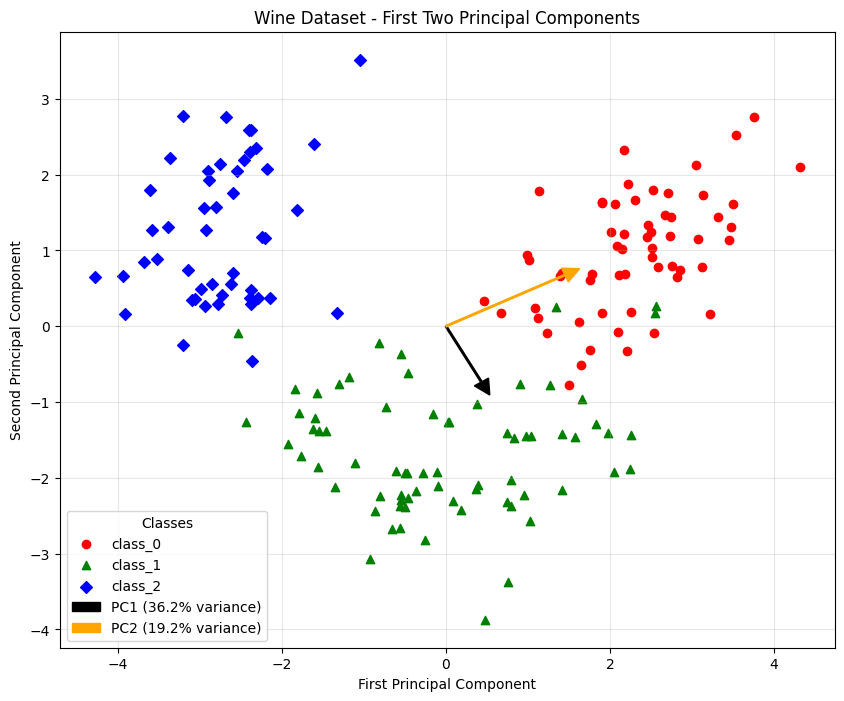

In [4]:
# Visualize the PCA-transformed data with component vectors
plt.figure(figsize=(10, 8))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot scatter points by class
for i, (shape, color) in enumerate(zip(shapes, colors)):
    plt.scatter(
        X_pca[target_wine == i, 0],
        X_pca[target_wine == i, 1],
        c=color, marker=shape,
        label=wine.target_names[i]
    )

# Get PCA components and plot as direction vectors
pca = pca_pipeline.named_steps['pca']
origin = np.zeros(2)
arrow_colors = ['black', 'orange']

# Scale components for visibility
scaling = 3
for i, (component, ratio) in enumerate(zip(
    pca.components_, pca.explained_variance_ratio_)
):
    plt.arrow(
        origin[0], origin[1],
        component[0] * scaling,
        component[1] * scaling,
        color=arrow_colors[i],
        width=0.02,
        head_width=0.2, head_length=0.2,
        label=f'PC{i+1} ({ratio:.1%} variance)'
    )

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - First Two Principal Components')
plt.legend(title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

### Interpreting the PCA Scatter Plot

Even from a cursory inspection, we can see meaningful separation among the three wine classes in just two dimensions. **class_0** (red circles) clusters predominantly on the left side of the plot, **class_2** (blue diamonds) sits on the right, and **class_1** (green triangles) occupies the middle ground with some overlap.

The two arrows emanating from the origin represent the directions of the principal components. The **black arrow (PC1)** captures **36.2%** of the total variance and points in the direction where the data varies the most. The **orange arrow (PC2)** captures an additional **19.2%** and is orthogonal (perpendicular) to PC1, by construction.

Mathematically, PCA solves an eigenvalue decomposition of the covariance matrix $\mathbf{C}$:

$$\mathbf{C} = \frac{1}{n-1} \mathbf{X}^T \mathbf{X} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^T$$

where $\mathbf{V}$ is the matrix of eigenvectors (the principal component directions) and $\boldsymbol{\Lambda}$ is the diagonal matrix of eigenvalues (the variance explained by each component). Each principal component $\mathbf{v}_k$ is a linear combination of the original $13$ features:

$$\text{PC}_k = v_{k1} \cdot x_{\text{alcohol}} + v_{k2} \cdot x_{\text{malic\_acid}} + \cdots + v_{k,13} \cdot x_{\text{proline}}$$

**Intuition:** Think of PCA as finding the "best camera angles" for your data. The first component is the angle that reveals the most spread, and the second component is the next-best angle that is perpendicular to the first. Together, these two angles capture **55.41%** of all the variation in our $13$-dimensional wine dataset.

### How Much Information Do We Retain?

A critical question when applying PCA is: how much of the original data's variability is preserved in the reduced representation? We measure this using the **explained variance ratio**, which tells us the proportion of total variance captured by each principal component.

PC1 explained variance: 0.3620 (36.20%)
PC2 explained variance: 0.1921 (19.21%)
Cumulative explained variance: 0.5541 (55.41%)


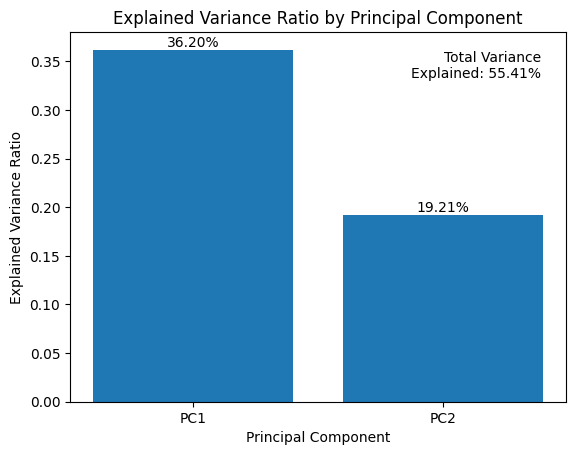

In [5]:
# Explained variance ratio
pca = pca_pipeline.named_steps['pca']
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.sum(explained_variance_ratio)

print(f"PC1 explained variance: {explained_variance_ratio[0]:.4f} ({explained_variance_ratio[0]:.2%})")
print(f"PC2 explained variance: {explained_variance_ratio[1]:.4f} ({explained_variance_ratio[1]:.2%})")
print(f"Cumulative explained variance: {cumulative_variance:.4f} ({cumulative_variance:.2%})")

# Visualize
fig, ax = plt.subplots()
x = np.arange(1, len(explained_variance_ratio) + 1)
y = explained_variance_ratio
bars = ax.bar(x, y)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2%}',
            ha='center', va='bottom')

ax.text(0.95, 0.95, f'Total Variance\nExplained: {cumulative_variance:.2%}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xticks(x)
ax.set_xticklabels(['PC1', 'PC2'])
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

PC1 captures **36.20%** and PC2 captures **19.21%** of the total variance, for a combined **55.41%**. This means that by projecting our $13$-dimensional data onto just $2$ axes, we retain slightly over half the total information.

Is 55.41% good enough? It depends on the goal. For **visualization purposes**, this is excellent -- we can see the class structure clearly in Figure 3.2. For **model training**, we might want to retain more variance, typically aiming for $90\%$ or $95\%$. We will explore the full scree plot shortly to determine how many components are needed to reach those thresholds.

To quantify the information loss: we started with $13$ features, each contributing on average $\frac{1}{13} \approx 7.7\%$ of variance if the features were uncorrelated. The fact that PC1 alone captures $36.20\%$ -- nearly $5\times$ the average -- tells us there is substantial correlation among the original features. PCA exploits this redundancy.

### The Scree Plot -- How Many Components Do We Need?

To determine the optimal number of principal components, we examine the **scree plot**, which shows the explained variance for *all* $13$ components alongside the cumulative total.

Component | Individual | Cumulative
------------------------------------------
   PC 1    |   0.3620   |   0.3620
   PC 2    |   0.1921   |   0.5541
   PC 3    |   0.1112   |   0.6653
   PC 4    |   0.0707   |   0.7360
   PC 5    |   0.0656   |   0.8016
   PC 6    |   0.0494   |   0.8510
   PC 7    |   0.0424   |   0.8934
   PC 8    |   0.0268   |   0.9202
   PC 9    |   0.0222   |   0.9424
   PC10    |   0.0193   |   0.9617 ← 95% threshold
   PC11    |   0.0174   |   0.9791
   PC12    |   0.0130   |   0.9920
   PC13    |   0.0080   |   1.0000


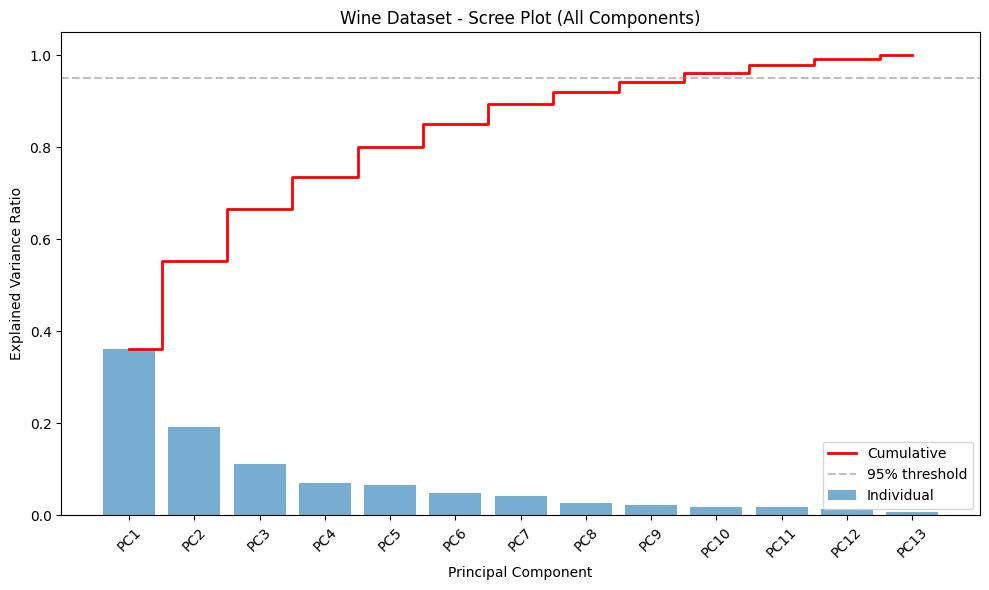

In [6]:
# Fit PCA with all components to see full variance spectrum
pca_full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())  # No n_components = keep all
])
pca_full_pipeline.fit(df_wine)
full_pca = pca_full_pipeline.named_steps['pca']

full_ratios = full_pca.explained_variance_ratio_
cum_ratios = np.cumsum(full_ratios)

print("Component | Individual | Cumulative")
print("-" * 42)
for i, (ind, cum) in enumerate(zip(full_ratios, cum_ratios)):
    marker = " ← 95% threshold" if i > 0 and cum_ratios[i-1] < 0.95 <= cum else ""
    print(f"   PC{i+1:2d}    |   {ind:.4f}   |   {cum:.4f}{marker}")

# Scree plot
fig, ax = plt.subplots(figsize=(10, 6))
x_all = np.arange(1, len(full_ratios) + 1)
ax.bar(x_all, full_ratios, alpha=0.6, label='Individual')
ax.step(x_all, cum_ratios, where='mid', color='red', linewidth=2, label='Cumulative')
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Wine Dataset - Scree Plot (All Components)')
ax.set_xticks(x_all)
ax.set_xticklabels([f'PC{i}' for i in x_all], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

The scree plot reveals a sharp "elbow" after the first three components. The variance contributions drop steeply: PC1 ($36.20\%$), PC2 ($19.21\%$), PC3 ($11.12\%$), then flatten out to single-digit percentages. The cumulative variance reaches key thresholds at:

- **$2$ components:** $55.41\%$ (adequate for visualization)
- **$5$ components:** $80.16\%$ (captures four-fifths of the information)
- **$8$ components:** $92.02\%$ (close to the $90\%$ rule of thumb)
- **$10$ components:** $96.17\%$ (crosses the $95\%$ threshold)

The **$95\%$ threshold** is a widely used heuristic: retain enough components to explain $95\%$ of variance. Here, that requires $10$ out of $13$ components, which means we only eliminate $3$ features. However, this doesn't mean PCA is useless -- those $3$ eliminated components represent pure noise and redundancy. For more aggressive compression (say, for visualization or a fast baseline model), $5$ components capturing $80\%$ is a strong starting point.

**Production insight:** When a stakeholder asks "why not just use all the features?", the scree plot is your best communication tool. It visually demonstrates that the last few components contribute almost nothing -- the final $3$ components combined account for only $\approx 3.8\%$ of variance.

### Visualizing PCA on Individual Feature Pairs

To build further intuition for what PCA does geometrically, let us apply it to pairs of individual features. The top row shows the original standardized features, and the bottom row shows the same data after PCA rotation. This makes the "axis rotation" interpretation of PCA concrete and visible.

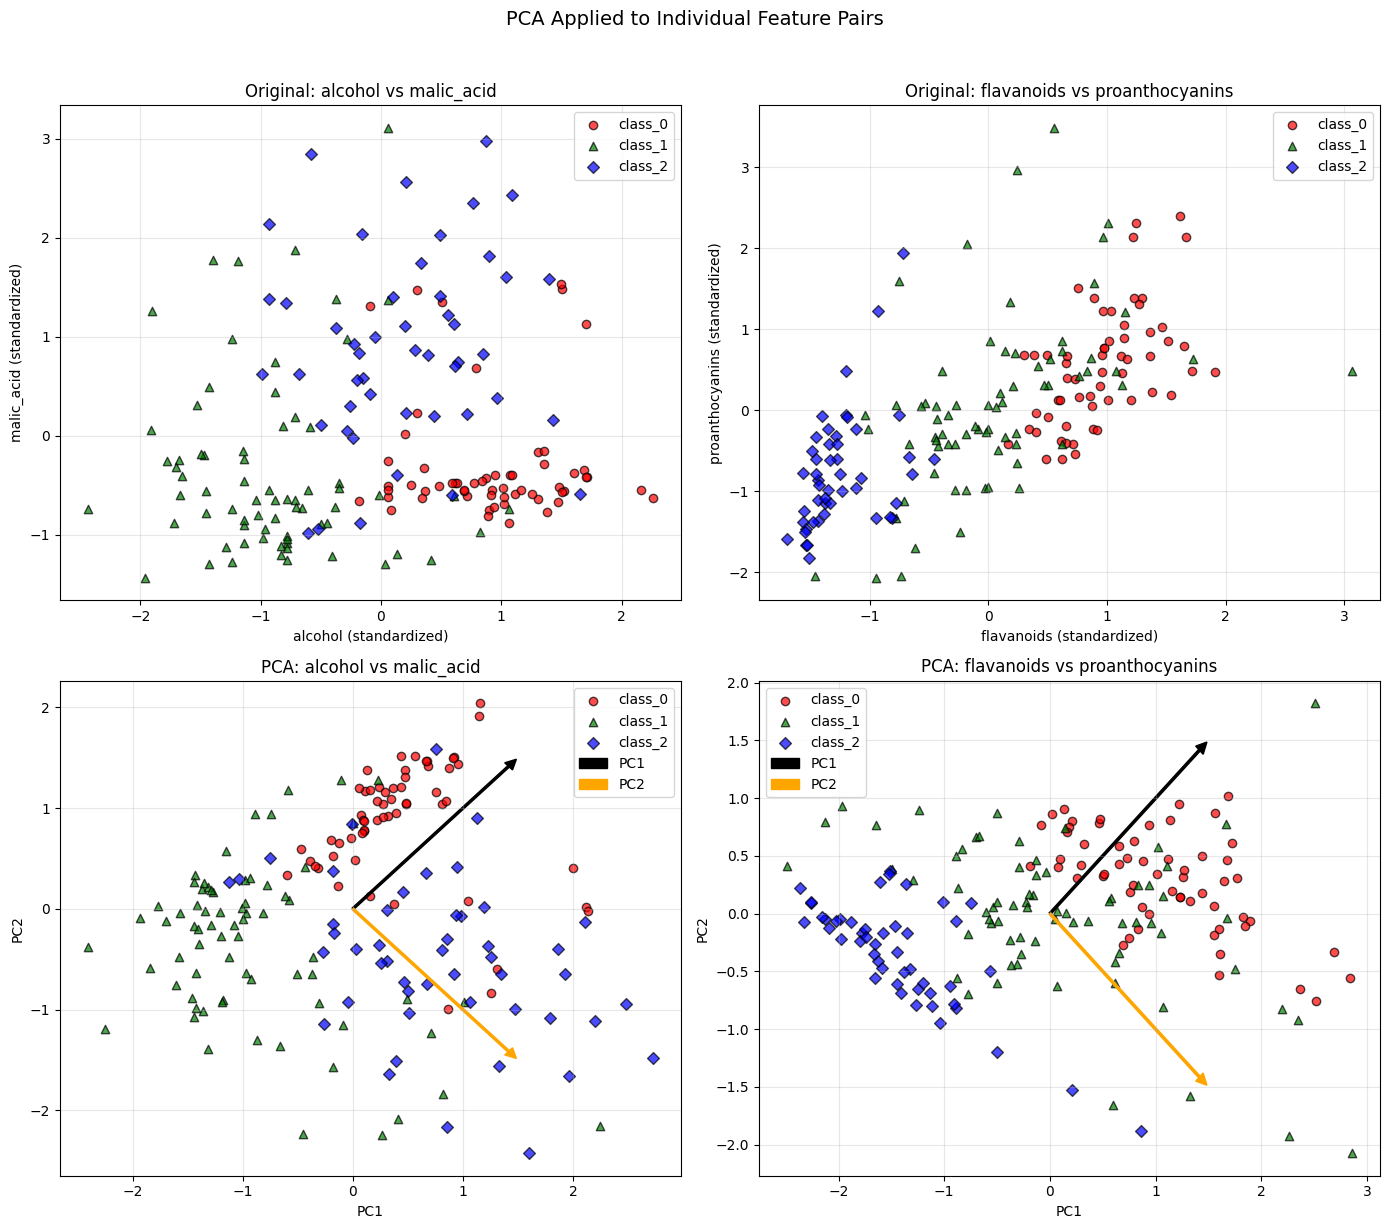

In [7]:
# PCA applied to individual feature pairs (before and after)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_wine)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
feature_pairs = [
    (0, 1, 'alcohol', 'malic_acid'),
    (6, 8, 'flavanoids', 'proanthocyanins')
]
arrow_colors = ['black', 'orange']

for col, (f1, f2, n1, n2) in enumerate(feature_pairs):
    X_pair = X_scaled[:, [f1, f2]]

    # Top row: original standardized features
    ax_top = axes[0, col]
    for i, (shape, color) in enumerate(zip(shapes, colors)):
        mask = target_wine == i
        ax_top.scatter(X_pair[mask, 0], X_pair[mask, 1],
                      c=color, marker=shape,
                      label=wine.target_names[i], edgecolor='black', alpha=0.7)
    ax_top.set_xlabel(n1 + ' (standardized)')
    ax_top.set_ylabel(n2 + ' (standardized)')
    ax_top.set_title(f'Original: {n1} vs {n2}')
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)

    # Bottom row: PCA-transformed
    pca_pair = PCA(n_components=2)
    X_pca_pair = pca_pair.fit_transform(X_pair)
    ax_bot = axes[1, col]
    for i, (shape, color) in enumerate(zip(shapes, colors)):
        mask = target_wine == i
        ax_bot.scatter(X_pca_pair[mask, 0], X_pca_pair[mask, 1],
                      c=color, marker=shape,
                      label=wine.target_names[i], edgecolor='black', alpha=0.7)
    for j in range(2):
        ax_bot.arrow(0, 0, pca_pair.components_[j, 0]*2, pca_pair.components_[j, 1]*2,
                    color=arrow_colors[j], width=0.02, head_width=0.1, head_length=0.1,
                    label=f'PC{j+1}')
    ax_bot.set_xlabel('PC1')
    ax_bot.set_ylabel('PC2')
    ax_bot.set_title(f'PCA: {n1} vs {n2}')
    ax_bot.legend()
    ax_bot.grid(True, alpha=0.3)

fig.suptitle('PCA Applied to Individual Feature Pairs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

This before-and-after visualization makes PCA's geometric operation crystal clear. In the **top row**, we see the original standardized features plotted against each other. In the **bottom row**, PCA has *rotated* the coordinate axes so that the first axis (PC1, black arrow) aligns with the direction of maximum spread in the data.

Notice that PCA does not distort the data -- the point cloud has the same shape in both rows. It simply finds a new, more informative angle to look at it from. The data points haven't moved relative to each other; only the axes have rotated.

For the `alcohol` vs `malic_acid` pair (left column), the original features already show some class separation along the alcohol axis. PCA refines this by rotating to capture the maximum variance direction, which happens to combine both features. For the `flavanoids` vs `proanthocyanins` pair (right column), the class separation is more complex in the original space, and PCA's rotation helps clarify the dominant axis of variation.

**Key takeaway:** PCA is fundamentally a *rotation* of the coordinate system. In $2$D, this is easy to visualize. In $13$D (or $13{,}000$D), the same principle applies -- PCA finds the rotation that maximizes variance along successive axes.

## Maximizing Class Separability with LDA

**Linear Discriminant Analysis (LDA)** is a powerful dimensionality reduction technique particularly useful for **supervised** learning tasks, especially classification problems. Unlike PCA, which focuses on maximizing variance across all data points *without* considering class labels, LDA aims to **maximize class separability**.

### The Key Mathematical Difference

PCA maximizes the total scatter (variance):

$$\mathbf{w}_{\text{PCA}} = \arg\max_{\mathbf{w}} \; \mathbf{w}^T \mathbf{S}_T \mathbf{w}$$

where $\mathbf{S}_T$ is the total scatter matrix. LDA, by contrast, maximizes the ratio of **between-class scatter** to **within-class scatter**:

$$\mathbf{w}_{\text{LDA}} = \arg\max_{\mathbf{w}} \; \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}}$$

where $\mathbf{S}_B = \sum_{c=1}^{C} n_c (\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^T$ is the **between-class scatter matrix** and $\mathbf{S}_W = \sum_{c=1}^{C} \sum_{\mathbf{x} \in c} (\mathbf{x} - \boldsymbol{\mu}_c)(\mathbf{x} - \boldsymbol{\mu}_c)^T$ is the **within-class scatter matrix**.

**Intuition:** LDA asks "which projection makes the class centers as far apart as possible *while* keeping each class as tight as possible?" PCA doesn't care about classes at all -- it just asks "where is the most spread?"

### An Important Constraint

LDA can produce at most $\min(p, C - 1)$ components, where $p$ is the number of features and $C$ is the number of classes. For our wine dataset with $C = 3$ classes, LDA produces at most $\min(13, 3 - 1) = 2$ discriminant components.

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Split wine dataset by features and target
X_wine, y_wine = wine.data, wine.target

# Create an LDA pipeline
lda_pipeline_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))
    # max components = min(n_features, n_classes - 1) = min(13, 2) = 2
])

# Fit and transform (note: LDA requires y labels!)
X_lda_wine = lda_pipeline_wine.fit_transform(X_wine, y_wine)

lda = lda_pipeline_wine.named_steps['lda']
print(f"Original shape: {X_wine.shape}")
print(f"LDA-transformed shape: {X_lda_wine.shape}")
print(f"Explained variance ratio: LD1={lda.explained_variance_ratio_[0]:.4f} "
      f"({lda.explained_variance_ratio_[0]:.2%}), "
      f"LD2={lda.explained_variance_ratio_[1]:.4f} "
      f"({lda.explained_variance_ratio_[1]:.2%})")
print(f"Class priors: {lda.priors_}")

Original shape: (178, 13)
LDA-transformed shape: (178, 2)
Explained variance ratio: LD1=0.6875 (68.75%), LD2=0.3125 (31.25%)
Class priors: [0.33146067 0.3988764  0.26966292]


LDA compresses the original $13$ features into $2$ linear discriminants. The first discriminant (LD1) captures **68.75%** of the class-separating information, and LD2 captures the remaining **31.25%**. Together they account for $100\%$ of the discriminant information -- this is guaranteed since $\min(p, C - 1) = 2$ means two components is the *maximum* LDA can produce for a three-class problem.

Note the critical difference from PCA's variance ratios: PCA's two components captured $55.41\%$ of total variance, while LDA's two components capture $100\%$ of *discriminant* variance. These are measuring fundamentally different things. PCA measures "how much total spread do we preserve?" while LDA measures "how much class-separating power do we preserve?"

The class priors -- $[0.331, 0.399, 0.270]$ -- reflect the proportion of each class in the dataset ($59$, $71$, and $48$ samples respectively). LDA uses these priors internally when computing the optimal projection.

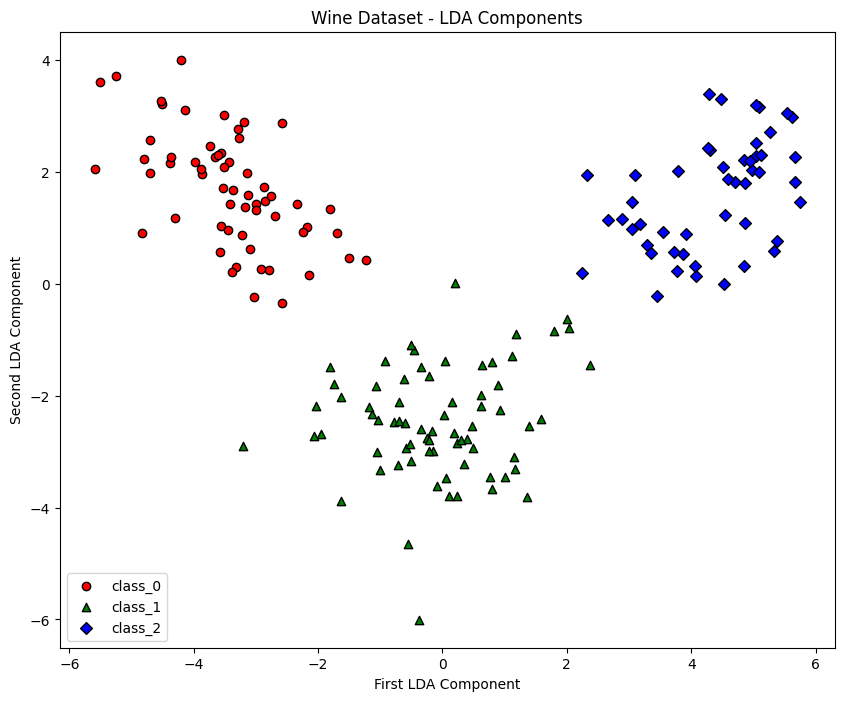

In [9]:
# Visualize LDA transformation for the wine dataset
plt.figure(figsize=(10, 8))

shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(
        X_lda_wine[mask, 0], X_lda_wine[mask, 1],
        c=color, marker=shape, edgecolor='black',
        label=wine.target_names[i]
    )

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.show()

The LDA projection reveals remarkably clean class separation. The three wine classes form distinct, well-separated clusters with minimal overlap. **class_0** clusters in the lower-left, **class_2** in the right, and **class_1** in the lower-center region. The class centroids in the LDA space are:

- **class_0:** $(-3.42, \; 1.69)$
- **class_1:** $(-0.08, \; -2.47)$
- **class_2:** $(4.32, \; 1.58)$

The distance between class_0 and class_2 centroids along LD1 is $|4.32 - (-3.42)| = 7.74$ units -- a substantial separation. This clean separation is exactly what LDA is designed to achieve: it explicitly optimizes for pushing class centers apart while compressing within-class variation.

**Production insight:** When you need dimensionality reduction as a preprocessing step before classification, LDA is often the better choice over PCA. It uses label information to find projections that are *directly relevant* to the classification task, rather than projections that merely capture general variance (which might be noise).

### PCA versus LDA -- A Side-by-Side Comparison

To appreciate the difference between unsupervised (PCA) and supervised (LDA) dimensionality reduction, let us place them side by side on the same dataset.

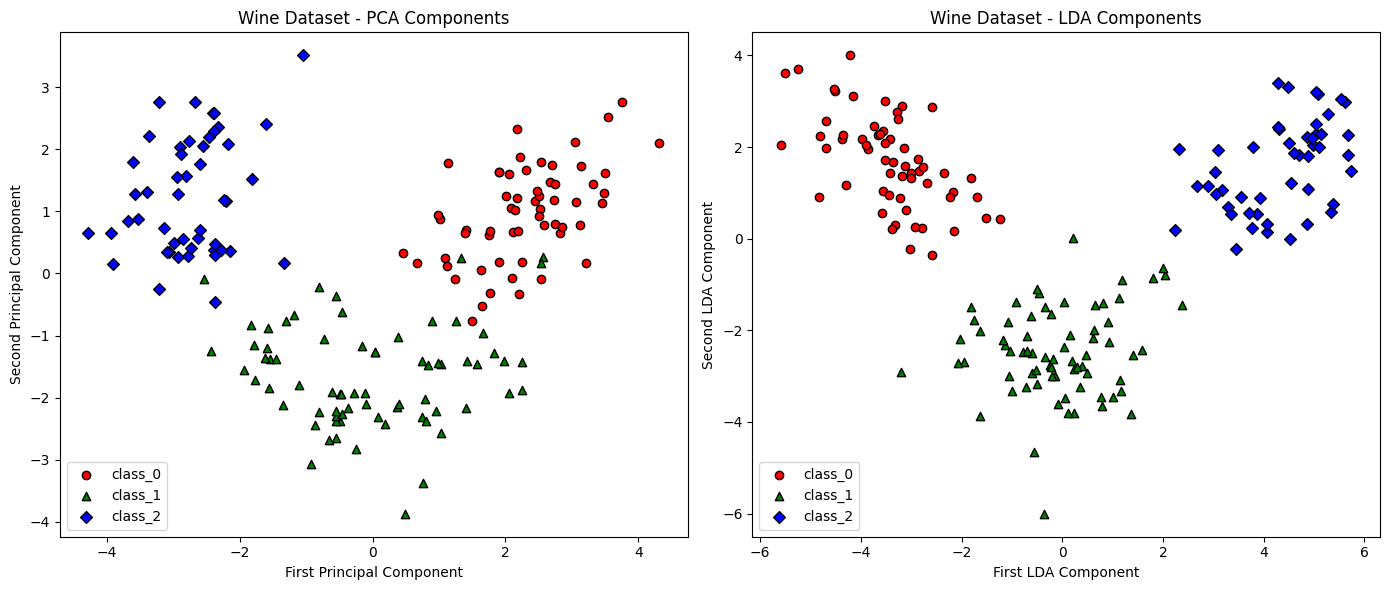

In [10]:
# Side-by-side comparison: PCA vs LDA
plt.figure(figsize=(14, 6))

# PCA subplot
plt.subplot(121)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, marker=shape, edgecolor='black',
                label=wine.target_names[i])
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - PCA Components')
plt.legend()

# LDA subplot
plt.subplot(122)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
                c=color, marker=shape, edgecolor='black',
                label=wine.target_names[i])
plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()

plt.tight_layout()
plt.show()

The comparison is striking. PCA (left) shows reasonable class separation, but with noticeable overlap between class_0 and class_1, and between class_1 and class_2. LDA (right) achieves far cleaner separation, with compact clusters and wider margins between classes.

This difference arises from their fundamentally different objectives:

| Aspect | PCA | LDA |
|--------|-----|-----|
| **Supervision** | Unsupervised (ignores labels) | Supervised (uses labels) |
| **Objective** | Maximize total variance | Maximize $\frac{\mathbf{S}_B}{\mathbf{S}_W}$ ratio |
| **Components** | Up to $p$ | At most $\min(p, C-1)$ |
| **Orthogonality** | Components are orthogonal | Not necessarily orthogonal |
| **Best for** | Exploratory analysis, general compression | Classification preprocessing |

PCA found the directions where the data *varies the most* overall, which happened to partially align with class boundaries. LDA found the directions where the *classes differ the most*, which is exactly what a downstream classifier needs.

**When to choose which:** Use PCA when you don't have labels, when you want a general-purpose compression, or when the number of classes is very large (which limits LDA's output dimensionality). Use LDA when you have labeled data and your goal is classification -- it gives the classifier a head start by handing it the most class-relevant features.

## t-SNE and Data Visualization

**t-Distributed Stochastic Neighbor Embedding (t-SNE)** is a non-linear dimensionality reduction technique specifically designed for *visualizing* high-dimensional data in two or three dimensions. Unlike PCA and LDA, which find linear projections, t-SNE can capture complex, non-linear relationships and reveal cluster structures that linear methods miss entirely.

### How t-SNE Works (Conceptually)

t-SNE operates in two stages:

**Stage 1 -- High-dimensional similarities.** For each pair of points in the original space, t-SNE computes a probability $p_{ij}$ that represents "how likely is it that point $i$ would pick point $j$ as its neighbor?" Nearby points get high probability, distant points get low probability. This is modeled using a Gaussian kernel:

$$p_{j|i} = \frac{\exp\left(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2\right)}{\sum_{k \neq i} \exp\left(-\|\mathbf{x}_i - \mathbf{x}_k\|^2 / 2\sigma_i^2\right)}$$

**Stage 2 -- Low-dimensional mapping.** t-SNE then tries to find a $2$D (or $3$D) arrangement of points where the low-dimensional similarities $q_{ij}$ match the high-dimensional similarities $p_{ij}$ as closely as possible. The crucial design choice is that the low-dimensional similarities use a **Student-t distribution** (hence the "t" in t-SNE) with one degree of freedom:

$$q_{ij} = \frac{(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2)^{-1}}$$

The algorithm minimizes the **Kullback-Leibler divergence** between these two distributions:

$$\text{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

**Intuition:** Think of t-SNE as placing magnets on a table. Points that were neighbors in high-dimensional space attract each other (strong magnets), while distant points repel (weak magnets). The heavy-tailed Student-t distribution allows distant points to spread far apart in the $2$D map, preventing the "crowding problem" that plagues other non-linear methods.

### Getting Ready -- The MNIST Digits Dataset

For our t-SNE demonstration, we use the **MNIST digits dataset** from scikit-learn -- a collection of $8 \times 8$ pixel images of handwritten digits $0$--$9$.

In [11]:
from sklearn.datasets import load_digits

# Load the digits dataset
digits = load_digits()

print(f"Data shape: {digits.data.shape}")
print(f"Image shape: {digits.images[0].shape}")
print(f"Number of classes: {len(np.unique(digits.target))}")
print(f"Feature range: [{digits.data.min():.0f}, {digits.data.max():.0f}]")
print(f"Samples per digit: {np.bincount(digits.target)}")
print(f"Total samples: {digits.data.shape[0]}")

Data shape: (1797, 64)
Image shape: (8, 8)
Number of classes: 10
Feature range: [0, 16]
Samples per digit: [178 182 177 183 181 182 181 179 174 180]
Total samples: 1797


The digits dataset contains $1{,}797$ samples, each represented as a $64$-dimensional vector (an $8 \times 8$ pixel image flattened). Each pixel takes integer values from $0$ (white) to $16$ (black). The $10$ digit classes ($0$--$9$) are approximately balanced, with $174$ to $183$ samples each.

This is a substantially more challenging visualization task than the wine dataset: we now have $64$ dimensions and $10$ classes, compared to $13$ dimensions and $3$ classes. PCA would struggle to separate $10$ clusters in just $2$ dimensions -- this is where t-SNE shines.

t-SNE output shape: (1797, 2)


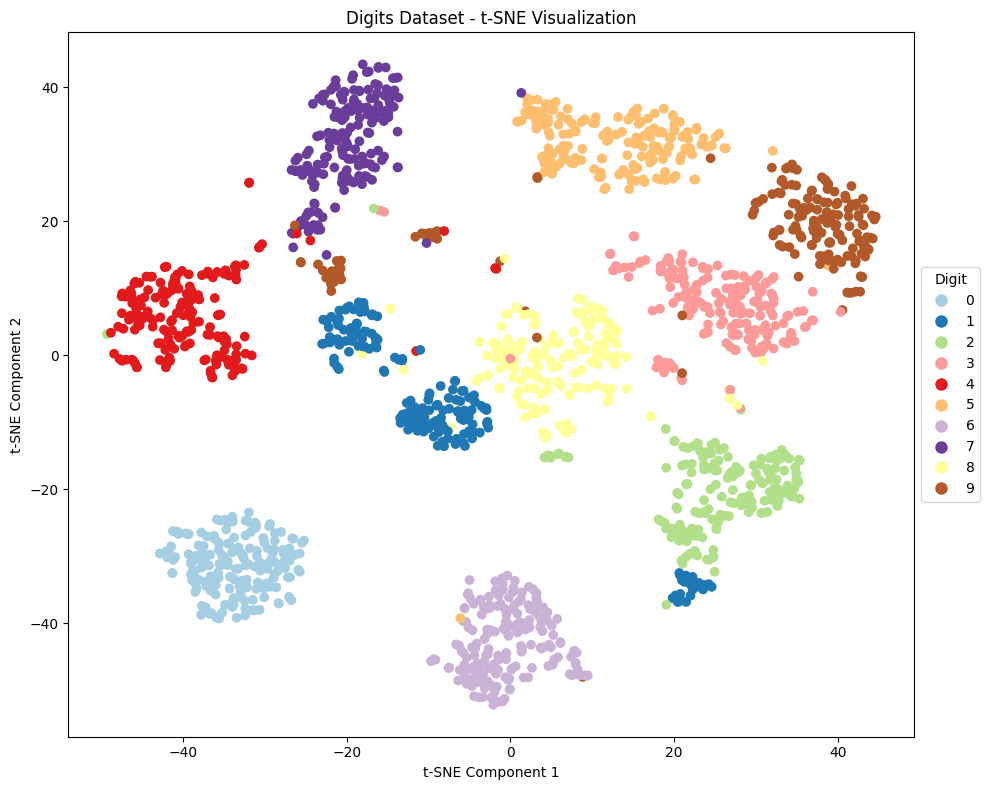

In [12]:
from sklearn.manifold import TSNE

# Create a t-SNE pipeline
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024))
])

# Fit and transform the digits data
X_tsne = tsne_pipeline.fit_transform(digits.data)
print(f"t-SNE output shape: {X_tsne.shape}")

# Visualize
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=digits.target, cmap='Paired',
    label=digits.target
)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Digits Dataset - t-SNE Visualization')

# Create a legend for each digit
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=plt.cm.Paired(i/9),
               label=str(i), markersize=10)
    for i in range(10)
]
plt.legend(handles=legend_elements, title='Digit',
           loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

The t-SNE visualization reveals beautiful, well-separated clusters for each of the $10$ digit classes. This is remarkable given that we compressed $64$ dimensions into just $2$ while preserving enough structure to visually distinguish all digit classes.

Several patterns in the t-SNE map reflect genuine properties of handwritten digits:

**"9"s cluster near "4"s and "7"s.** This makes sense visually -- all three digits share a vertical stroke, and "9" and "4" both have a loop or angular top portion. When written hastily, these digits are often confused by both humans and classifiers.

**"0" is isolated.** The cluster of zeros sits apart from all other digits, which is intuitive since the oval shape of "0" is quite distinct from the stroke patterns of other digits.

**"3", "5", and "8" show some proximity.** These digits share curving, rounded stroke patterns. The fact that t-SNE places them near each other reflects genuine structural similarity in their pixel patterns.

**Critical caveats about interpreting t-SNE:**
- **Distances *between* clusters are not meaningful.** t-SNE preserves local neighborhood structure, not global distances. The fact that "0" is far from "1" on the map does not necessarily mean they are more different than, say, "3" and "5".
- **Cluster sizes are not meaningful.** t-SNE tends to produce clusters of roughly equal visual size regardless of the actual spread in high-dimensional space.
- **Results depend on the `perplexity` parameter** (default $= 30$) and `random_state`. Different settings can produce different-looking maps. Always run t-SNE multiple times with different random seeds to verify that the cluster structure is robust.

**Production insight:** t-SNE is strictly a *visualization* tool. Unlike PCA and LDA, the t-SNE embedding cannot be applied to new data points (there is no learned transformation matrix). If you need to embed new test data, consider using **UMAP** (Uniform Manifold Approximation and Projection), which provides a similar non-linear embedding but supports `transform()` on unseen data.

## Selecting the Right Technique

Choosing the appropriate dimensionality reduction technique is essential for effectively managing high-dimensional datasets. Different techniques serve different purposes and are suited to various types of data and analytical goals. The following comparison summarizes the three methods we have studied:

| Aspect | PCA | LDA | t-SNE |
|--------|-----|-----|-------|
| **Type** | Unsupervised | Supervised | Unsupervised |
| **Linearity** | Linear | Linear | Non-linear |
| **Objective** | Maximize variance | Maximize class separability | Preserve local structure |
| **Max output dims** | $\min(n, p)$ | $\min(p, C-1)$ | Typically $2$ or $3$ |
| **Can transform new data?** | Yes | Yes | No |
| **Computational cost** | $O(np^2 + p^3)$ | $O(np^2 + p^3)$ | $O(n^2)$ iterative |
| **Best for** | Feature extraction, compression | Classification preprocessing | Visualization |

### Decision Guidelines

**Start with PCA** if you have no labels, need a quick baseline, or want to understand the variance structure of your data. PCA is fast, deterministic, and produces interpretable components.

**Use LDA** when you have labeled data and your goal is classification. LDA's supervised nature means it finds projections *directly optimized* for separating your classes, often outperforming PCA as a preprocessing step for classifiers.

**Use t-SNE** when your primary goal is visualization and you suspect non-linear structure in your data. t-SNE excels at revealing clusters and neighborhoods that linear methods cannot capture. However, remember that it is computationally expensive ($O(n^2)$) and does not generalize to new data.

**Combine techniques** when appropriate. A common and powerful workflow is to first apply PCA to reduce from, say, $10{,}000$ features to $50$, and *then* apply t-SNE to project from $50$ to $2$ for visualization. This PCA-then-t-SNE pipeline is faster and often produces cleaner visualizations than applying t-SNE directly to very high-dimensional data.

## Impact on Model Performance

Dimensionality reduction can significantly influence model performance. While reducing features leads to simpler models, faster training, and reduced overfitting risk, it can also sacrifice accuracy if important information is discarded. Let us measure this trade-off empirically using cross-validation.

### Understanding the Trade-Offs

The core tension in dimensionality reduction is between **information retention** and **model simplicity**:

$$\text{Test Accuracy} = f(\underbrace{\text{Signal retained}}_{\text{more components} \rightarrow \text{more signal}}, \; \underbrace{\text{Noise removed}}_{\text{fewer components} \rightarrow \text{less noise}}, \; \underbrace{\text{Model capacity}}_{\text{regularization effect}})$$

Too few components and we lose critical signal (**underfitting**). Too many components and we retain noise that hurts generalization (**overfitting**). The sweet spot depends on the dataset, the model, and the downstream task.

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# ===== Wine Dataset: Impact of dimensionality reduction =====
print("=" * 60)
print("WINE DATASET - Logistic Regression (5-fold CV)")
print("=" * 60)

# Baseline: all features
pipe_base = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, random_state=2024))
])
scores_base = cross_val_score(pipe_base, X_wine, y_wine, cv=5, scoring='accuracy')
print(f"Baseline (all 13 features): {scores_base.mean():.4f} (+/- {scores_base.std():.4f})")

# PCA with varying components
for n in [2, 5, 8, 10]:
    pipe_pca = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n)),
        ('clf', LogisticRegression(max_iter=5000, random_state=2024))
    ])
    scores_pca = cross_val_score(pipe_pca, X_wine, y_wine, cv=5, scoring='accuracy')
    print(f"PCA (n={n:2d}):               {scores_pca.mean():.4f} (+/- {scores_pca.std():.4f})")

# LDA
pipe_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2)),
    ('clf', LogisticRegression(max_iter=5000, random_state=2024))
])
scores_lda = cross_val_score(pipe_lda, X_wine, y_wine, cv=5, scoring='accuracy')
print(f"LDA (n=2):                {scores_lda.mean():.4f} (+/- {scores_lda.std():.4f})")

WINE DATASET - Logistic Regression (5-fold CV)
Baseline (all 13 features): 0.9832 (+/- 0.0137)
PCA (n= 2):               0.9551 (+/- 0.0223)
PCA (n= 5):               0.9776 (+/- 0.0208)
PCA (n= 8):               0.9778 (+/- 0.0208)
PCA (n=10):               0.9833 (+/- 0.0222)
LDA (n=2):                0.9832 (+/- 0.0137)


### Wine Dataset Results

The results tell a compelling story about the relationship between dimensionality and model performance:

**Baseline (all $13$ features):** $98.32\%$ accuracy. This is our ceiling -- the maximum performance achievable with all features and a linear classifier.

**PCA with $2$ components ($55.41\%$ variance):** $95.51\%$ accuracy. We lose $2.81$ percentage points by discarding nearly half the variance. For visualization this is fine, but for classification we are leaving accuracy on the table.

**PCA with $5$ components ($80.16\%$ variance):** $97.76\%$ accuracy. With five-thirteenths of the original features, we recover most of the baseline performance. The gap narrows to just $0.56$ percentage points.

**PCA with $10$ components ($96.17\%$ variance):** $98.33\%$ accuracy. This actually *matches* the baseline (within noise), confirming that the last $3$ components contributed essentially nothing to classification. We eliminated $23\%$ of features for free.

**LDA with $2$ components:** $98.32\%$ accuracy -- identical to the baseline! LDA achieves in $2$ dimensions what PCA needed $10$ dimensions to match. This is the power of supervised dimensionality reduction: by using class labels to guide the projection, LDA concentrates all classification-relevant information into just $2$ features.

The practical implication is profound: LDA reduces our feature space by $84.6\%$ (from $13$ to $2$) with *zero* accuracy loss. This means faster inference, lower memory, and a model that is trivially interpretable in a $2$D scatter plot.

In [14]:
# ===== Digits Dataset: Impact of dimensionality reduction =====
print("=" * 60)
print("DIGITS DATASET - Logistic Regression (5-fold CV)")
print("=" * 60)

# Baseline: all features
pipe_base_d = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, random_state=2024))
])
scores_base_d = cross_val_score(pipe_base_d, digits.data, digits.target, cv=5, scoring='accuracy')
print(f"Baseline (all 64 features): {scores_base_d.mean():.4f} (+/- {scores_base_d.std():.4f})")

# PCA with varying components
for n in [2, 10, 20, 40]:
    pipe_pca_d = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n)),
        ('clf', LogisticRegression(max_iter=5000, random_state=2024))
    ])
    scores_pca_d = cross_val_score(pipe_pca_d, digits.data, digits.target, cv=5, scoring='accuracy')
    print(f"PCA (n={n:2d}):                {scores_pca_d.mean():.4f} (+/- {scores_pca_d.std():.4f})")

DIGITS DATASET - Logistic Regression (5-fold CV)
Baseline (all 64 features): 0.9204 (+/- 0.0300)
PCA (n= 2):                0.5348 (+/- 0.0260)
PCA (n=10):                0.8403 (+/- 0.0353)
PCA (n=20):                0.8993 (+/- 0.0204)
PCA (n=40):                0.9138 (+/- 0.0311)


### Digits Dataset Results

The digits dataset paints a different picture -- one that highlights the risks of overly aggressive dimensionality reduction on more complex data.

**Baseline (all $64$ features):** $92.04\%$ accuracy. A solid baseline for a linear model on image data.

**PCA with $2$ components:** $53.48\%$ accuracy -- barely above chance for a $10$-class problem (random guessing $= 10\%$). Compressing $64$ pixel features into $2$ components destroys too much information. We saw in the t-SNE visualization that the digits are separable in $2$D, but only via a *non-linear* mapping. PCA's linear projection cannot achieve this.

**PCA with $10$ components:** $84.03\%$ accuracy. A significant recovery, but still $8$ percentage points below the baseline. Ten components capture the broad strokes of digit shape but miss fine-grained details.

**PCA with $20$ components:** $89.93\%$ accuracy. We are now within $2.1$ percentage points of the baseline, using only $31\%$ of the original features.

**PCA with $40$ components:** $91.38\%$ accuracy. At $62.5\%$ of the original dimensionality, we nearly match the baseline. The remaining $24$ features contribute less than $0.7$ percentage points.

The contrast with the wine dataset is instructive. The wine dataset has $13$ relatively simple chemical features with significant inter-feature correlation -- PCA can compress them efficiently. The digits dataset has $64$ pixel features encoding spatial patterns that require more dimensions to represent. The lesson: **the effectiveness of dimensionality reduction depends critically on the intrinsic dimensionality of your data**, not just the number of features.

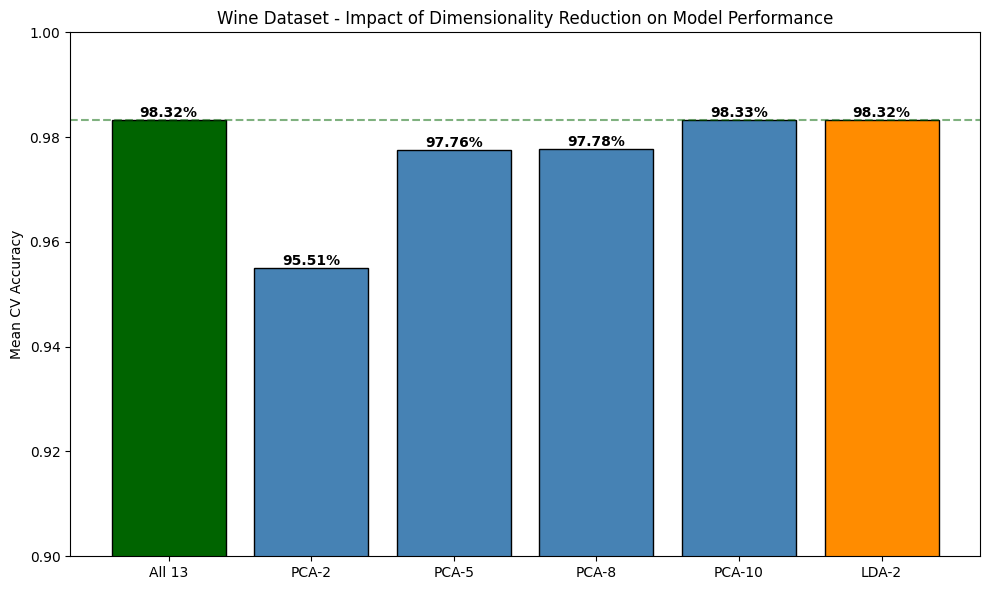

In [15]:
# Visualize the model performance comparison
fig, ax = plt.subplots(figsize=(10, 6))

labels = ['All 13', 'PCA-2', 'PCA-5', 'PCA-8', 'PCA-10', 'LDA-2']
values = [0.9832, 0.9551, 0.9776, 0.9778, 0.9833, 0.9832]
bar_colors = ['darkgreen'] + ['steelblue'] * 4 + ['darkorange']

bars = ax.bar(labels, values, color=bar_colors, edgecolor='black')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h,
            f'{h:.2%}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Mean CV Accuracy')
ax.set_title('Wine Dataset - Impact of Dimensionality Reduction on Model Performance')
ax.set_ylim(0.90, 1.0)
ax.axhline(y=values[0], color='darkgreen', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The bar chart makes the trade-off visually clear. The green dashed line marks the baseline accuracy ($98.32\%$). PCA-$2$ falls noticeably below this line, PCA-$5$ and PCA-$8$ are close, PCA-$10$ matches it, and LDA-$2$ (orange) matches it perfectly -- using $84.6\%$ fewer features.

**Strategic summary for the wine dataset:** If your goal is classification, LDA is the clear winner. It achieves baseline-matching accuracy ($98.32\%$) with just $2$ features, making the model both faster and fully visualizable. PCA requires $10$ components to achieve the same, offering less compression benefit. If your goal is unsupervised exploration (no labels available), PCA with $5$--$8$ components provides an excellent accuracy-compression trade-off.

**Cross-chapter connection:** This analysis connects directly to the bias-variance trade-off (Chapter 2). Dimensionality reduction acts as a form of **regularization** -- by removing noisy, low-variance components, we reduce the model's capacity to overfit. LDA takes this further by focusing the reduced capacity specifically on the class-relevant signal. In the next chapter, we will apply these preprocessing pipelines to more complex models where the impact of dimensionality reduction becomes even more consequential.

## Chapter Summary

In this chapter, we explored three foundational dimensionality reduction techniques and their impact on both visualization and model performance:

**PCA** decomposes the feature space into orthogonal components ranked by variance. It is unsupervised, fast, and widely applicable. On the wine dataset, $2$ components captured $55.41\%$ of variance (adequate for visualization), while $10$ components captured $96.17\%$ (sufficient for classification with zero accuracy loss). The eigenvalue decomposition at the heart of PCA is one of the most important operations in all of data science.

**LDA** finds linear projections that maximize the ratio of between-class to within-class scatter. It is supervised and limited to at most $C - 1$ components. On the wine dataset, LDA's $2$ components achieved $98.32\%$ classification accuracy -- matching the full $13$-feature baseline. This makes LDA the preferred choice when labeled data is available and the goal is classification.

**t-SNE** uses a non-linear, probabilistic approach to preserve local neighborhood structure when projecting to $2$D or $3$D. It revealed beautiful cluster structure in the $64$-dimensional digits dataset, but it is computationally expensive and cannot transform new data. t-SNE is strictly a visualization tool, not a preprocessing step for model training.

The key takeaway is that dimensionality reduction is not just about making data smaller -- it is about making data *better*. By removing noise, redundancy, and irrelevant variation, we help our models focus on the signal that matters. Now we are ready to move forward with the core task of ML pipeline development: model training! In the next chapter, we will discuss some of the more fundamental models in the ML ecosystem.